In [12]:
import os
import dynamic_sound as ds
import matplotlib.pyplot as plt
import librosa
import IPython.display as ipd
import numpy as np
import pyroomacoustics as pra

SMALL_SIZE = 18
MEDIUM_SIZE = 22
BIGGER_SIZE = 26

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [13]:
fs = 8_000
mic_sample_rate = fs
microphone_path = ds.Path([
    [5.0,  0, 0, 0,   1, 0, 0, 0],
    [6.0,  0, 0, 0,   1, 0, 0, 0]
])

## Perfect sine wave

In [14]:
# simulation environment
sim = ds.Simulation(
    temperature=20,
    pressure=1,
    relative_humidity=50
)

# microphone
sim.add_microphone(
    path=microphone_path,
    microphone=ds.microphones.Microphone(
        file_path="_tmp/no_interpolation.wav",
        sample_rate=mic_sample_rate,
        directivity=ds.microphones.DirectivityType.OMNIDIRECTIONAL
    )
)

# source
sim.add_source(
    path=ds.Path([
        [0.0, 50, 0, 0,   1, 0, 0, 0],
        [10.0, 0, 0, 0,   1, 0, 0, 0]
    ]),
    source=ds.sources.SineWave(
        frequency=3_000,
        amplitude=1.0,
        directivity=ds.sources.DirectivityType.OMNIDIRECTIONAL
    )
)

sim.run()

  0%|          | 0/8000 [00:00<?, ?it/s]

100%|██████████| 8000/8000 [00:14<00:00, 539.41it/s]


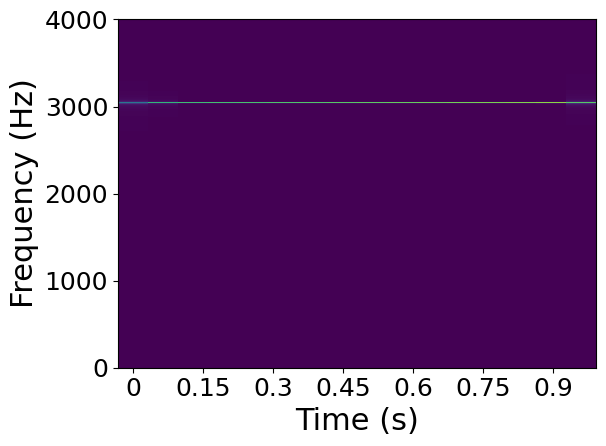

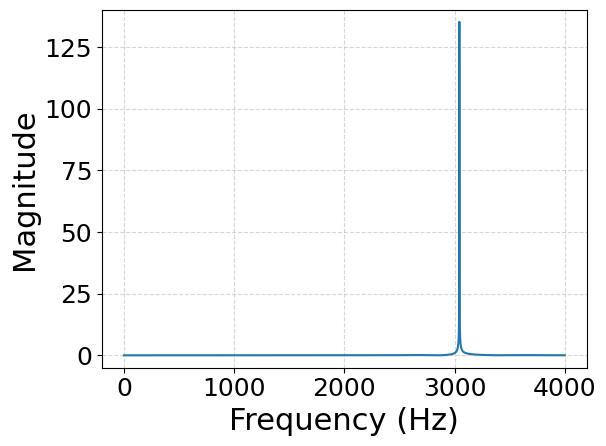

In [15]:
signal, sr = librosa.load("_tmp/no_interpolation.wav", sr=None, mono=False)

if signal.ndim == 1:  # if single channel reshape to a common format (n_channels, n_samples)
    signal = signal.reshape(1, -1)

D = librosa.stft(signal[0])
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure()
librosa.display.specshow(np.abs(D), sr=sr, x_axis='time', y_axis='fft', cmap='viridis')
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
#plt.ylim(0, 4000)
# plt.colorbar(format='%+2.0f dB')
#plt.title('Spectrogram')
plt.tight_layout()
plt.savefig("_tmp/sine_8k_spec.png", dpi=300)
plt.show()

# --- FFT ---
X = np.fft.rfft(signal[0])
N = len(signal[0])
freq = np.fft.rfftfreq(N, d=1/sr)

# magnitude to dB
mag = np.abs(X)
mag_db = 20 * np.log10(mag)

plt.figure()
#plt.plot(freq, mag_db, color='C0')
#plt.loglog(freq, mag, color='C0')
plt.plot(freq, mag, color='C0')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
# plt.title('Single-sided FFT of the signal (unnormalized amplitude)')
# plt.xlim(0, sr / 2)
plt.ylim(-5, 140)
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.tight_layout()
plt.savefig("_tmp/sine_8k_mag.png", dpi=300)
plt.show()

In [16]:
# simulation environment
sim = ds.Simulation(
    temperature=20,
    pressure=1,
    relative_humidity=50
)

# microphone
sim.add_microphone(
    path=microphone_path,
    microphone=ds.microphones.Microphone(
        file_path="_tmp/interpolation_linear.wav",
        sample_rate=mic_sample_rate,
        directivity=ds.microphones.DirectivityType.OMNIDIRECTIONAL
    )
)

# source
signal, info = ds.generators.sine_generator(f=3_000, fs=fs, amplitude=1.0, length="period", filename="_tmp/sine_3000.wav")
print(info)
sim.add_source(
    path=ds.Path([
        [0.0, 50, 0, 0,   1, 0, 0, 0],
        [10.0, 0, 0, 0,   1, 0, 0, 0]
    ]),
    source=ds.sources.AudioSignal(
        signal=signal,
        sample_rate=fs,
        gain_db=0.0,
        loop=True,
        interpolation=ds.sources.InterpolationType.LINEAR,
        directivity=ds.sources.DirectivityType.OMNIDIRECTIONAL
    )
)

sim.run()

{'frequency': 3000, 'samples': 8, 'duration': 0.001, 'cycles': 3.0}


  0%|          | 0/8000 [00:00<?, ?it/s]

100%|██████████| 8000/8000 [00:13<00:00, 611.16it/s]


0.046611004


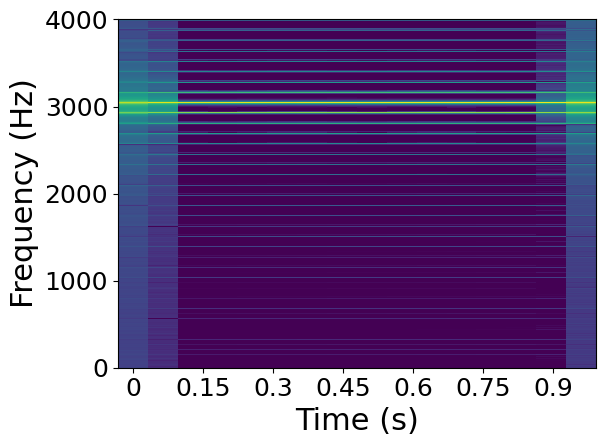

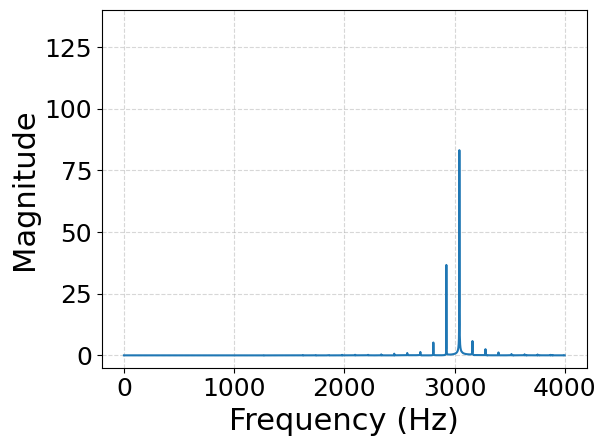

In [17]:
signal, sr = librosa.load("_tmp/interpolation_linear.wav", sr=None, mono=False)

if signal.ndim == 1:  # if single channel reshape to a common format (n_channels, n_samples)
    signal = signal.reshape(1, -1)

print(max(signal[0]))
ipd.display(ipd.Audio(signal[0], rate=sr))

D = librosa.stft(signal[0])
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure()
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='fft', cmap='viridis')
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
#plt.ylim(0, 4000)
# plt.colorbar(format='%+2.0f dB')
#plt.title('Spectrogram')
plt.tight_layout()
plt.savefig("_tmp/sine_linear_8k_spec.png", dpi=300)
plt.show()

# --- FFT ---
X = np.fft.rfft(signal[0])
N = len(signal[0])
freq = np.fft.rfftfreq(N, d=1/sr)

# magnitude to dB
mag = np.abs(X)
mag_db = 20 * np.log10(mag)

plt.figure()
#plt.plot(freq, mag_db, color='C0')
#plt.loglog(freq, mag, color='C0')
plt.plot(freq, mag, color='C0')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
# plt.title('Single-sided FFT of the signal (unnormalized amplitude)')
# plt.xlim(0, sr / 2)
# plt.ylim(1e-6, 1e1)
plt.ylim(-5, 140)
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.tight_layout()
plt.savefig("_tmp/sine_linear_8k_mag.png", dpi=300)
plt.show()

In [18]:
# simulation environment
sim = ds.Simulation(
    temperature=20,
    pressure=1,
    relative_humidity=50
)

# microphone
sim.add_microphone(
    path=microphone_path,
    microphone=ds.microphones.Microphone(
        file_path="_tmp/interpolation_sinc.wav",
        sample_rate=mic_sample_rate,
        directivity=ds.microphones.DirectivityType.OMNIDIRECTIONAL
    )
)

# source
signal, info = ds.generators.sine_generator(f=3_000, fs=fs, amplitude=1.0, length="period", filename="_tmp/sine_3000.wav")
print(info)
sim.add_source(
    path=ds.Path([
        [0.0, 50, 0, 0,   1, 0, 0, 0],
        [10.0, 0, 0, 0,   1, 0, 0, 0]
    ]),
    source=ds.sources.AudioSignal(
        signal=signal,
        sample_rate=fs,
        gain_db=0.0,
        loop=True,
        interpolation=ds.sources.InterpolationType.SINC,
        directivity=ds.sources.DirectivityType.OMNIDIRECTIONAL
    )
)

sim.run()

{'frequency': 3000, 'samples': 8, 'duration': 0.001, 'cycles': 3.0}


100%|██████████| 8000/8000 [00:15<00:00, 514.90it/s]


0.0470108


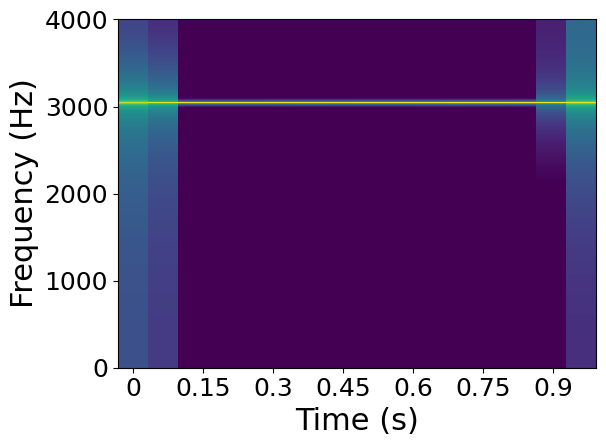

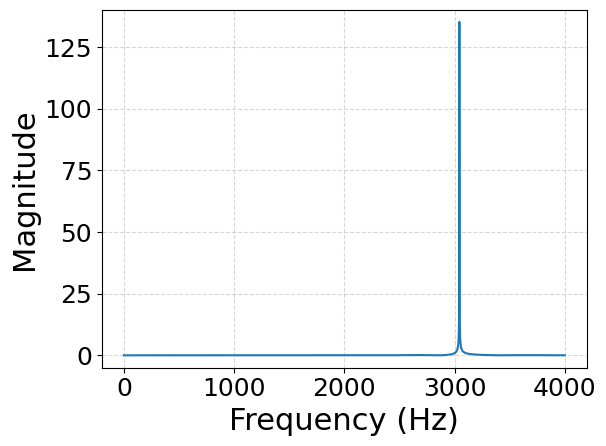

In [19]:
signal, sr = librosa.load("_tmp/interpolation_sinc.wav", sr=None, mono=False)

if signal.ndim == 1:  # if single channel reshape to a common format (n_channels, n_samples)
    signal = signal.reshape(1, -1)

print(max(signal[0]))
ipd.display(ipd.Audio(signal[0], rate=sr))

D = librosa.stft(signal[0])
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure()
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='fft', cmap='viridis')
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
#plt.ylim(0, 4000)
# plt.colorbar(format='%+2.0f dB')
#plt.title('Spectrogram')
plt.tight_layout()
plt.savefig("_tmp/sine_sinc_8k_spec.png", dpi=300)
plt.show()

# --- FFT ---
X = np.fft.rfft(signal[0])
N = len(signal[0])
freq = np.fft.rfftfreq(N, d=1/sr)

# magnitude to dB
mag = np.abs(X)
mag_db = 20 * np.log10(mag)

plt.figure()
#plt.plot(freq, mag_db, color='C0')
#plt.loglog(freq, mag, color='C0')
plt.plot(freq, mag, color='C0')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
# plt.title('Single-sided FFT of the signal (unnormalized amplitude)')
# plt.xlim(0, sr / 2)
plt.ylim(-5, 140)
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.tight_layout()
plt.savefig("_tmp/sine_sinc_8k_mag.png", dpi=300)
plt.show()

In [20]:
fs = 48_000


# simulation environment
sim = ds.Simulation(
    temperature=20,
    pressure=1,
    relative_humidity=50
)

# microphone
mic_sample_rate = fs
sim.add_microphone(
    path=microphone_path,
    microphone=ds.microphones.Microphone(
        file_path="_tmp/interpolation_48000.wav",
        sample_rate=mic_sample_rate,
        directivity=ds.microphones.DirectivityType.OMNIDIRECTIONAL
    )
)

# source
signal, info = ds.generators.sine_generator(f=3_000, fs=fs, amplitude=1.0, length="period", filename="_tmp/sine_3000.wav")
print(info)
sim.add_source(
    path=ds.Path([
        [0.0, 50, 0, 0,   1, 0, 0, 0],
        [10.0, 0, 0, 0,   1, 0, 0, 0]
    ]),
    source=ds.sources.AudioSignal(
        signal=signal,
        sample_rate=fs,
        gain_db=0.0,
        loop=True,
        interpolation=ds.sources.InterpolationType.LINEAR,
        directivity=ds.sources.DirectivityType.OMNIDIRECTIONAL
    )
)

sim.run()

{'frequency': 3000, 'samples': 16, 'duration': 0.0003333333333333333, 'cycles': 1.0}


100%|██████████| 48000/48000 [01:26<00:00, 556.99it/s]


0.046873868


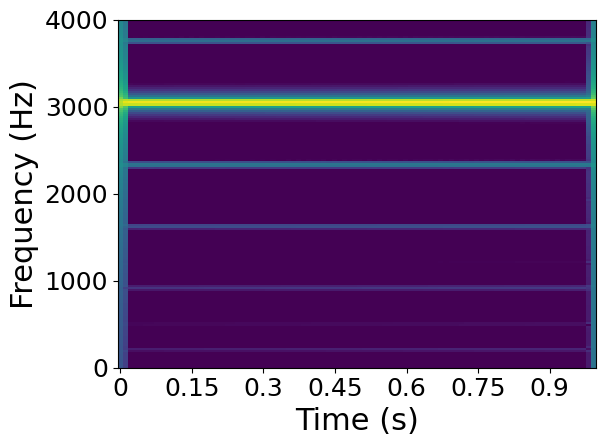

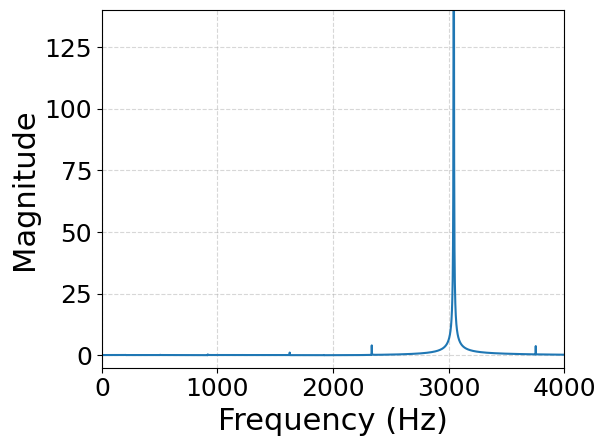

In [21]:
signal, sr = librosa.load("_tmp/interpolation_48000.wav", sr=None, mono=False)

if signal.ndim == 1:  # if single channel reshape to a common format (n_channels, n_samples)
    signal = signal.reshape(1, -1)

print(max(signal[0]))
ipd.display(ipd.Audio(signal[0], rate=sr))

D = librosa.stft(signal[0])
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure()
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='fft', cmap='viridis')
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.ylim(0, 4000)
# plt.colorbar(format='%+2.0f dB')
#plt.title('Spectrogram')
plt.tight_layout()
plt.savefig("_tmp/sine_librosa_8k_spec.png", dpi=300)
plt.show()

# --- FFT ---
X = np.fft.rfft(signal[0])
N = len(signal[0])
freq = np.fft.rfftfreq(N, d=1/sr)

# magnitude to dB
mag = np.abs(X)
mag_db = 20 * np.log10(mag)

plt.figure()
plt.plot(freq, mag, color='C0')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
# plt.title('Single-sided FFT of the signal (unnormalized amplitude)')
plt.xlim(0, 4000)
plt.ylim(-5, 140)
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.tight_layout()
plt.savefig("_tmp/sine_librosa_8k_mag.png", dpi=300)
plt.show()